### 1. Descargar csv

In [1]:
from datetime import datetime
import pandas as pd

def descargar_datos():
    hoy = datetime.today().strftime("%Y-%m-%d")

    url = (
        "https://earthquake.usgs.gov/fdsnws/event/1/query?"
        f"format=csv&starttime=2000-01-01&endtime={hoy}"
        "&minlatitude=0"
        "&maxlatitude=13.5"
        "&minlongitude=-74"
        "&maxlongitude=-59"
        "&orderby=time"
    )

    df = pd.read_csv(url)
    df.to_csv("../data/raw/terremotos_venezuela.csv", index=False)

    return df

df = descargar_datos()

df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-07-26T02:13:46.744Z,4.7907,-72.7547,12.362,4.7,mb,63.0,57.0,1.142,0.70,...,2026-07-26T02:33:31.040Z,"18 km ESE of Monterrey, Colombia",earthquake,7.20,4.654,0.038,204.0,reviewed,us,us
1,2026-07-23T17:50:29.177Z,6.8042,-73.1257,147.537,4.6,mb,79.0,82.0,0.907,0.79,...,2026-07-23T18:10:00.716Z,"8 km NNW of Jordán, Colombia",earthquake,7.36,7.732,0.039,193.0,reviewed,us,us
2,2026-07-20T10:55:00.820Z,10.6707,-62.2023,66.041,4.8,mb,50.0,41.0,3.568,1.24,...,2026-07-20T20:40:39.721Z,"14 km NE of Güiria, Venezuela",earthquake,8.45,7.136,0.095,34.0,reviewed,us,us
3,2026-07-20T09:45:10.282Z,11.3742,-60.8041,83.510,5.2,mww,105.0,35.0,2.139,0.96,...,2026-07-22T11:47:04.040Z,"22 km NNW of Scarborough, Trinidad and Tobago",earthquake,8.28,6.670,0.073,18.0,reviewed,us,us
4,2026-07-20T01:44:14.908Z,6.7581,-73.0723,152.012,4.6,mb,59.0,44.0,0.860,0.87,...,2026-07-20T02:09:25.251Z,"3 km NE of Jordán, Colombia",earthquake,7.32,6.256,0.032,289.0,reviewed,us,us


In [2]:
# Copia del dataset original
df_venezuela = df.copy()

# Filtrar solo registros relacionados con Venezuela
df_venezuela = df_venezuela[
    df_venezuela["place"].str.contains("Venezuela", case=False, na=False)
]

print(df_venezuela.shape)
df_venezuela.to_csv("../data/processed/terremotos_venezuela_filtrado.csv", index=False)

(1119, 22)


### 2. Explorar Dataset

In [3]:
df_venezuela.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1119 entries, 2 to 3448
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             1119 non-null   object 
 1   latitude         1119 non-null   float64
 2   longitude        1119 non-null   float64
 3   depth            1119 non-null   float64
 4   mag              1114 non-null   float64
 5   magType          1108 non-null   object 
 6   nst              824 non-null    float64
 7   gap              960 non-null    float64
 8   dmin             367 non-null    float64
 9   rms              543 non-null    float64
 10  net              1119 non-null   object 
 11  id               1119 non-null   object 
 12  updated          1119 non-null   object 
 13  place            1119 non-null   object 
 14  type             1119 non-null   object 
 15  horizontalError  357 non-null    float64
 16  depthError       458 non-null    float64
 17  magError         31

In [4]:
df_venezuela.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')

In [5]:
df_venezuela["year"] = pd.to_datetime(df_venezuela["time"]).dt.year
df_venezuela.to_csv(
    "../data/processed/terremotos_venezuela_filtrado.csv",
    index=False
)
df_venezuela.head(10)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,year
2,2026-07-20T10:55:00.820Z,10.6707,-62.2023,66.041,4.8,mb,50.0,41.0,3.568,1.24,...,"14 km NE of Güiria, Venezuela",earthquake,8.45,7.136,0.095,34.0,reviewed,us,us,2026
6,2026-07-13T19:59:53.882Z,10.7234,-62.6404,88.024,4.5,mb,60.0,84.0,3.857,0.70,...,"26 km NE of Yaguaraparo, Venezuela",earthquake,4.51,6.691,0.067,66.0,reviewed,us,us,2026
7,2026-07-08T23:56:00.177Z,10.5193,-68.5580,10.000,4.5,mb,25.0,86.0,2.613,1.16,...,"15 km SE of Yumare, Venezuela",earthquake,7.36,1.898,0.164,11.0,reviewed,us,us,2026
8,2026-07-07T08:41:38.174Z,10.7833,-62.7846,126.309,4.5,mb,60.0,83.0,1.879,1.00,...,"24 km N of Yaguaraparo, Venezuela",earthquake,8.44,8.209,0.045,147.0,reviewed,us,us,2026
9,2026-06-29T11:01:02.693Z,10.7743,-66.7938,10.000,4.6,mb,108.0,58.0,2.251,0.53,...,"19 km NNE of Caraballeda, Venezuela",earthquake,6.36,1.881,0.042,169.0,reviewed,us,us,2026
10,2026-06-28T09:33:59.554Z,10.4907,-68.4852,10.000,4.3,mb,59.0,69.0,2.645,0.99,...,"23 km ESE of Yumare, Venezuela",earthquake,6.70,1.911,0.092,33.0,reviewed,us,us,2026
11,2026-06-28T08:46:09.312Z,10.6091,-68.3699,10.000,4.5,mb,41.0,175.0,2.814,0.74,...,"11 km SW of Boca de Aroa, Venezuela",earthquake,13.22,1.953,0.060,80.0,reviewed,us,us,2026
12,2026-06-27T19:20:37.253Z,10.6767,-67.6133,10.000,4.8,mww,72.0,41.0,3.018,0.80,...,"41 km N of El Limón, Venezuela",earthquake,7.01,1.876,0.110,8.0,reviewed,us,us,2026
13,2026-06-27T14:23:39.723Z,10.6024,-67.0541,10.000,4.3,mb,52.0,64.0,3.920,0.79,...,"2 km W of Catia La Mar, Venezuela",earthquake,8.21,1.884,0.101,29.0,reviewed,us,us,2026
14,2026-06-26T22:16:11.872Z,10.7968,-67.6011,10.000,4.7,mww,87.0,46.0,3.542,0.76,...,"54 km N of El Limón, Venezuela",earthquake,5.91,1.805,0.103,9.0,reviewed,us,us,2026


### 3. Terremoto más fuerte

In [6]:
df_venezuela.loc[df["mag"].idxmax()]

time                         2026-06-24T22:05:03.992Z
latitude                                      10.6221
longitude                                    -67.1935
depth                                            10.0
mag                                               7.5
magType                                           mww
nst                                              64.0
gap                                              38.0
dmin                                            0.406
rms                                              0.57
net                                                us
id                                         us6000t7zp
updated                      2026-07-30T03:16:35.789Z
place              17 km W of Catia La Mar, Venezuela
type                                       earthquake
horizontalError                                  6.41
depthError                                      1.888
magError                                        0.036
magNst                      

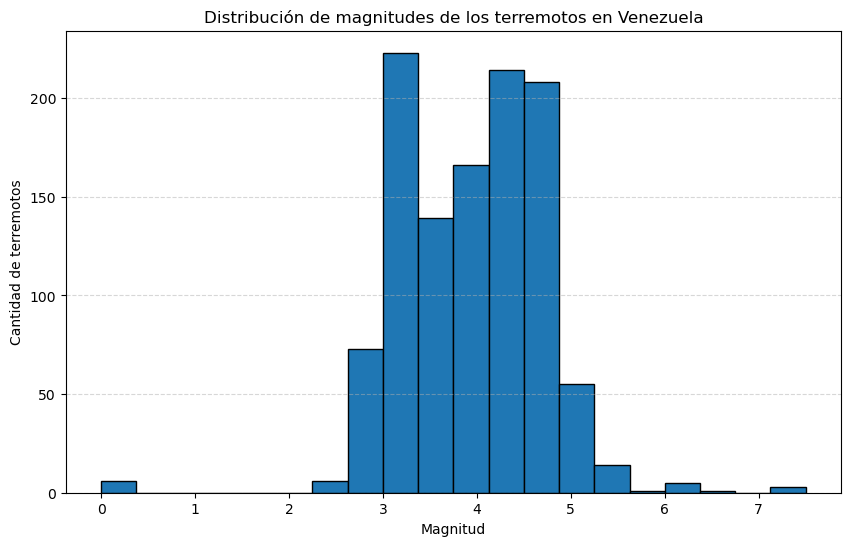

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df_venezuela["mag"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribución de magnitudes de los terremotos en Venezuela")
plt.xlabel("Magnitud")
plt.ylabel("Cantidad de terremotos")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [8]:
%pip install folium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
import folium

print("Folium cargado correctamente")
print(folium.__version__)

Folium cargado correctamente
0.20.0


In [10]:
mapa = folium.Map(location=[7.0, -66.0], zoom_start=6)


In [11]:
print(df_venezuela.shape)
print(df.shape)

(1119, 23)
(3449, 22)


In [12]:
df_venezuela["place"].value_counts().head(20)

place
near the coast of Venezuela       31
37 km N of Güiria, Venezuela       7
38 km NNE of Güiria, Venezuela     6
61 km NNE of Güiria, Venezuela     6
44 km N of Güiria, Venezuela       5
21 km WNW of Güiria, Venezuela     5
25 km NNW of Güiria, Venezuela     5
44 km NE of Güiria, Venezuela      5
34 km NNW of Güiria, Venezuela     5
32 km NNE of Güiria, Venezuela     5
33 km NNE of Güiria, Venezuela     5
42 km N of Güiria, Venezuela       5
18 km SSW of Güiria, Venezuela     5
37 km NNE of Güiria, Venezuela     4
80 km NNE of Güiria, Venezuela     4
63 km NNE of Güiria, Venezuela     4
31 km NNE of Güiria, Venezuela     4
49 km N of Güiria, Venezuela       4
36 km N of Güiria, Venezuela       4
27 km NNW of Güiria, Venezuela     4
Name: count, dtype: int64

In [13]:
#Crear estadistica
total_eventos = len(df_venezuela)
magnitud_max = df_venezuela["mag"].max()
magnitud_prom = df_venezuela["mag"].mean()
anio_inicio = df_venezuela["year"].min()
anio_fin = df_venezuela["year"].max()

In [14]:
for _, fila in df_venezuela.iterrows():

    if fila["mag"] >= 6:
        color = "red"
    elif fila["mag"] >= 5:
        color = "orange"
    else:
        color = "blue"

    folium.CircleMarker(
        location=[fila["latitude"], fila["longitude"]],
        radius=max(fila["mag"] * 0.6, 2),
        color=color,
        weight=1,
        fill=True,
        fill_color=color,
        fill_opacity=0.5,
        tooltip=f"{fila['place']} (M {fila['mag']})",
        popup=folium.Popup(
        f"""
        <b>📍Lugar:</b>{fila['place']}<br>
        <b>📈Magnitud:</b> {fila['mag']}<br>
        <b>📏Profundidad:</b> {fila['depth']} km<br>
        <b>📅Año:</b> {fila['year']}<br>
        """,
        max_width=300
      )
    ).add_to(mapa)

    legend_html = """
        <div style="
        position: fixed;
        bottom: 50px;
        left: 50px;
        width: 200px;
        background-color: white;
        border:2px solid grey;
        border-radius:10px;
        padding: 10px;
        font-size:14px;
        z-index:9999;
        box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
        ">

        <b>🌎 Magnitud de Terremotos</b><br><br>

        <span style="color:red;">●</span> Magnitud ≥ 6<br>
        <span style="color:orange;">●</span> Magnitud 5 - 5.9<br>
        <span style="color:blue;">●</span> Magnitud &lt; 5

        </div>
    """
    stats_html = f"""
    <div style="
    position: fixed;
    top: 20px;
    right: 20px;
    width: 250px;
    background: rgba(255,255,255,0.95);
    border-radius:12px;
    padding:15px;
    font-family:Arial;
    font-size:14px;
    box-shadow:0 0 15px rgba(0,0,0,0.3);
    z-index:9999;
    ">

    <h4 style="margin-top:0;">
    📊 Estadísticas
    </h4>

    <p>🌋 <b>Eventos:</b> {total_eventos}</p>

    <p>📈 <b>Magnitud máxima:</b> {magnitud_max:.1f}</p>

    <p>📉 <b>Magnitud promedio:</b> {magnitud_prom:.2f}</p>

    <p>📅 <b>Período:</b> {anio_inicio} - {anio_fin}</p>

    </div>
    """

mapa.get_root().html.add_child(folium.Element(stats_html))
mapa.get_root().html.add_child(folium.Element(legend_html))

mapa.save("mapa_terremotos_venezuela.html")

In [15]:
#Mostrar mapa
import webbrowser
import os

ruta = os.path.abspath("mapa_terremotos_venezuela.html")
webbrowser.open("file://" + ruta)

True